## Introduction

This project focuses on analysing and predicting water quality conditions in NSW coastal catchments using machine learning techniques. The aim is to classify water samples as either normal or high concern based on environmental indicators such as turbidity, nutrient levels, dissolved oxygen, and pH.

A K-Nearest Neighbours (KNN) classification model is used to predict whether water quality conditions will remain normal or become high concern in the next time period.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Description
The dataset contains water quality measurements collected from multiple NSW coastal catchments between 2016 and 2021. It includes physical and chemical indicators such as electrical conductivity, nitrogen, phosphorus, turbidity, dissolved oxygen saturation, and pH.

Each record represents a water sample collected at a specific station and time.

In [2]:
df = pd.read_csv("../data/wq_modelling.csv")
df.head()

,station,catchment,zone,sample_date,year,month,season,ec_us_cm,total_n_mg_l,nox_n_mg_l,...,turbidity_ntu,do_sat_pct,ph,risk_score,high_concern,turbidity_ntu_bad,tss_mg_l_bad,total_n_mg_l_bad,total_p_mg_l_bad,do_sat_pct_bad
0,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-06-28 11:45:00,2016,6,winter,230.0,1.10,0.42,...,34.0,NaN,NaN,3,1,1,0,1,1,0
1,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-08-18 12:27:00,2016,8,winter,260.0,0.52,0.19,...,16.9,108.0,7.8,1,0,0,0,0,1,0
2,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-09-29 11:18:00,2016,9,spring,340.0,0.36,0.01,...,5.4,101.0,8.1,0,0,0,0,0,0,0
3,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-10-26 10:21:00,2016,10,spring,350.0,0.22,0.01,...,5.7,112.0,8.3,0,0,0,0,0,0,0
4,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-11-29 08:57:00,2016,11,spring,330.0,0.28,0.01,...,6.8,119.0,8.2,1,0,0,0,0,1,0


The dataset was sorted chronologically based on sampling date to preserve time order. Missing values were handled using median imputation to ensure robustness against outliers.

Categorical variables such as season were converted into numerical format using one-hot encoding. Non-predictive columns such as station name, catchment, zone, and timestamp were removed to avoid noise in the model.

In [3]:
df = df.sort_values("sample_date").reset_index(drop=True)

To enable future prediction, a target variable was created by shifting the high concern label by one time step. This allows the model to learn patterns from current water conditions to predict the next month’s water quality status.

In [27]:
df["next_month_high_concern"] = df["high_concern"].shift(-1)

In [5]:
df_model = df.dropna(subset=["next_month_high_concern"])

In [6]:
df_model = pd.get_dummies(df_model, columns=["season"], drop_first=True)

In [7]:
df_model = df_model.drop(columns=[
    "station",
    "catchment",
    "zone",
    "sample_date"
])

In [8]:
X = df_model.drop(columns=["high_concern", "next_month_high_concern"])
y = df_model["next_month_high_concern"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

Instead of random splitting, a time-based split was used. The dataset was divided into training and testing sets without shuffling to simulate real-world forecasting conditions, where future data is not available during training.

In [10]:
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The K-Nearest Neighbours algorithm was selected for classification. KNN is a non-parametric model that classifies data based on the majority class among the nearest neighbouring samples in feature space. In this project, k was set to 5.

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [13]:
y_pred = knn.predict(X_test)

In [14]:
label_map = {0: "GOOD (Normal Water Quality)", 1: "BAD (High Concern Risk)"}

pred_labels = [label_map[i] for i in y_pred]

The model was evaluated using accuracy, precision, recall, F1-score, and confusion matrix. These metrics help assess both overall performance and class-wise prediction quality.

In [15]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Predicted_Label": pred_labels
})

results.head(30)

,Actual,Predicted,Predicted_Label
0,0.0,0.0,GOOD (Normal Water Quality)
1,0.0,0.0,GOOD (Normal Water Quality)
2,0.0,0.0,GOOD (Normal Water Quality)
3,0.0,0.0,GOOD (Normal Water Quality)
4,0.0,0.0,GOOD (Normal Water Quality)
5,0.0,0.0,GOOD (Normal Water Quality)
6,0.0,0.0,GOOD (Normal Water Quality)
7,0.0,0.0,GOOD (Normal Water Quality)
8,0.0,0.0,GOOD (Normal Water Quality)
9,0.0,0.0,GOOD (Normal Water Quality)


In [17]:
last_row = df.iloc[[-1]].copy()

In [18]:
X_new = last_row.drop(columns=[
    "high_concern",
    "sample_date",
    "station",
    "catchment",
    "zone"
])

In [19]:
X_new = pd.get_dummies(X_new, columns=["season"], drop_first=True)

# align with training columns
X_new = X_new.reindex(columns=X.columns, fill_value=0)


In [20]:
X_new = imputer.transform(X_new)
X_new = scaler.transform(X_new)

In [21]:
pred = knn.predict(X_new)[0]

In [22]:
last_row["high_concern"] = pred

In [23]:
df_extended = pd.concat([df, last_row], ignore_index=True)

In [24]:
df_extended.to_csv("../data/prednextmonthknn.csv", index=False)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7542087542087542

Classification Report:

              precision    recall  f1-score   support

         0.0       0.84      0.86      0.85       242
         1.0       0.32      0.29      0.30        55

    accuracy                           0.75       297
   macro avg       0.58      0.58      0.58       297
weighted avg       0.75      0.75      0.75       297


Confusion Matrix:

[[208  34]
 [ 39  16]]


## The model achieved moderate predictive performance. It was effective at identifying normal water conditions but showed lower performance in detecting high concern cases. This is reflected in lower recall for the high concern class, indicating that some risky water conditions were not correctly identified.

## This suggests that the dataset may have class imbalance, where normal conditions dominate the data distribution.

/var/folders/02/v225726j2rqdwt7yggx1jw4c0000gn/T/ipykernel_25651/1815105922.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="high_concern", data=df, palette="viridis")


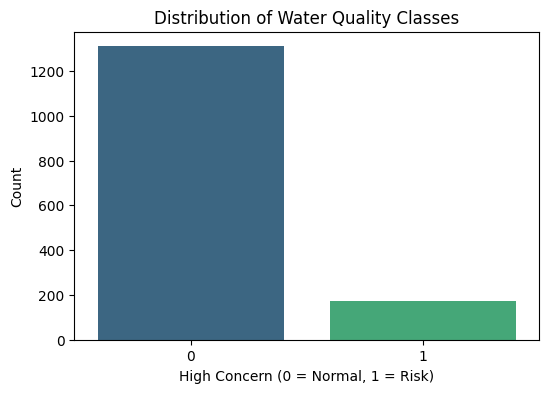

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="high_concern", data=df, palette="viridis")
plt.title("Distribution of Water Quality Classes")
plt.xlabel("High Concern (0 = Normal, 1 = Risk)")
plt.ylabel("Count")
plt.show()

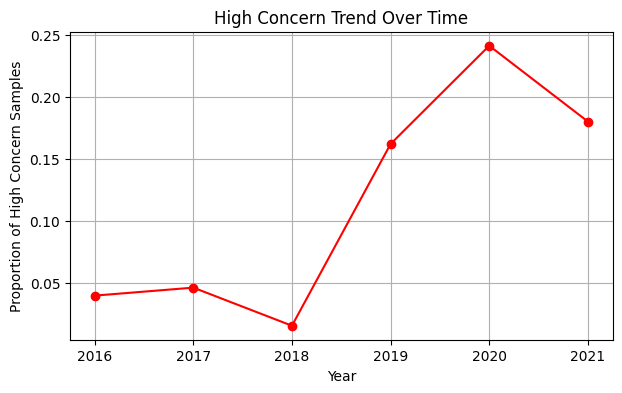

In [29]:
df_time = df.groupby("year")["high_concern"].mean()

plt.figure(figsize=(7,4))
df_time.plot(marker="o", color="red")
plt.title("High Concern Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Proportion of High Concern Samples")
plt.grid(True)
plt.show()

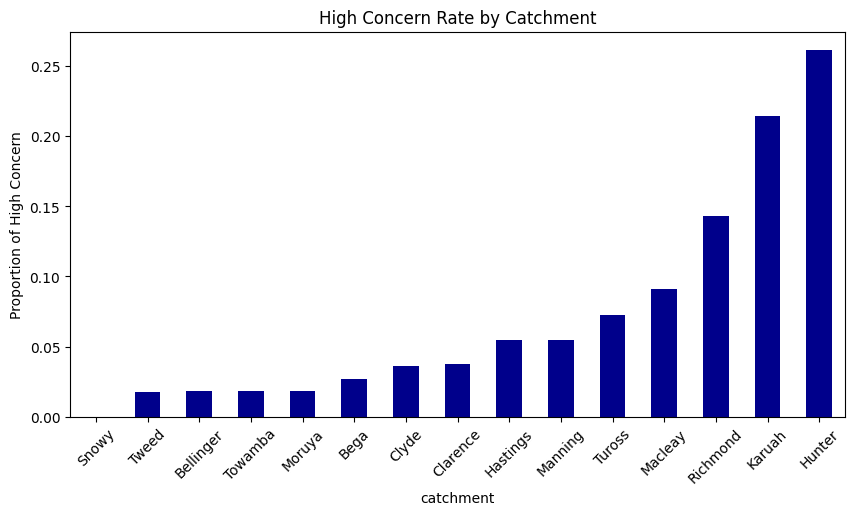

In [30]:
catchment_risk = df.groupby("catchment")["high_concern"].mean().sort_values()

plt.figure(figsize=(10,5))
catchment_risk.plot(kind="bar", color="darkblue")
plt.title("High Concern Rate by Catchment")
plt.ylabel("Proportion of High Concern")
plt.xticks(rotation=45)
plt.show()

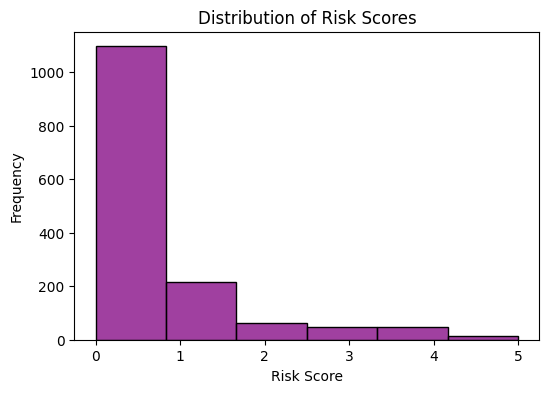

In [31]:
plt.figure(figsize=(6,4))
sns.histplot(df["risk_score"], bins=6, kde=False, color="purple")
plt.title("Distribution of Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

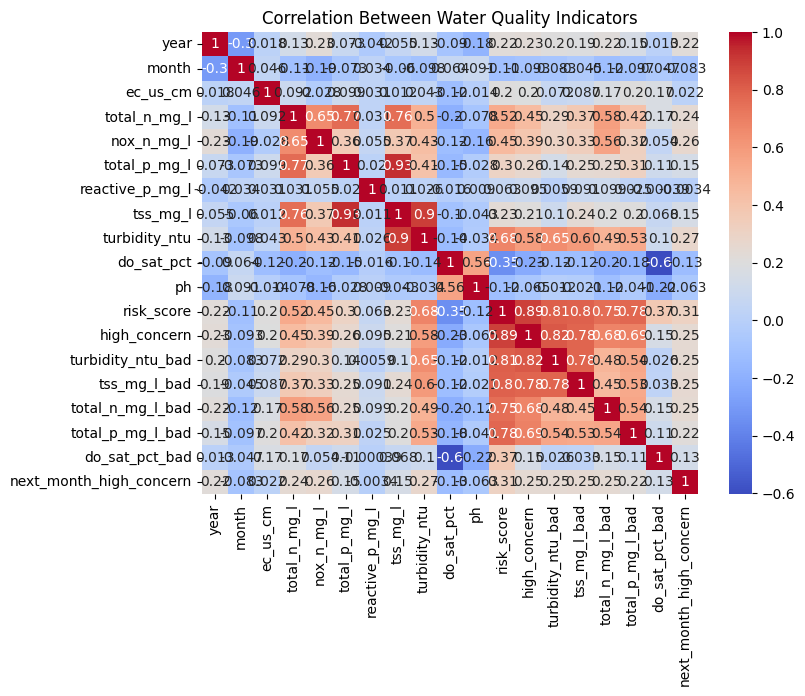

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Water Quality Indicators")
plt.show()

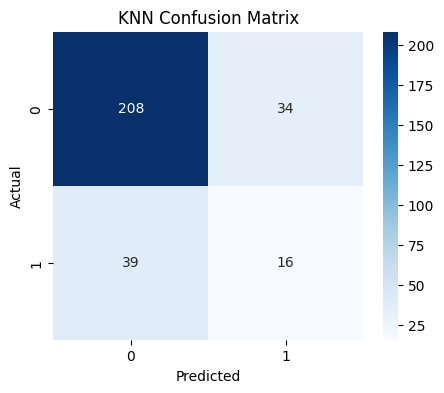

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()